<a href="https://colab.research.google.com/github/MateAlv/BioInformatica-Avanzada/blob/main/6_TopReviewersPerYear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/CienciaDeDatos/TP1/data/"

df_reviews = pd.read_csv(DATA_PATH + "reviews.csv")
df_clients = pd.read_csv(DATA_PATH + "customers.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Top contribuidores de Reviews por año

In [25]:
TOP_CLIENTS_SHOWED_PER_YEAR = 3

df_reviews_clean = df_reviews.loc[
    df_reviews['is_verified_purchase'] == True
      & df_reviews['is_verified_purchase'].notna(),
    ['customer_id', 'helpful_votes', 'created_at']]

df_reviews_clean['created_at'] = (df_reviews_clean['created_at'].astype(str).str.strip())
df_reviews_clean['created_at'] = pd.to_datetime(df_reviews_clean['created_at'], errors = 'coerce')
df_reviews_clean = df_reviews_clean.dropna(subset=['created_at'])
df_reviews_clean['year'] = df_reviews_clean['created_at'].dt.year

df_clients['name'] = df_clients['first_name'].str.title() + ' ' + df_clients['last_name'].str.title()
df_clients_clean = df_clients[['customer_id', 'name']]


df_clients_reviews = df_clients_clean.merge(df_reviews_clean, on='customer_id', how='inner')

df_clients_per_year = df_clients_reviews.groupby(['customer_id','name', 'year'], as_index=False).agg({'helpful_votes': 'sum'})

top_clients = (
    df_clients_per_year
      .sort_values(['year','helpful_votes'], ascending=[True, False])
      .groupby('year', group_keys=False)
      .head(TOP_CLIENTS_SHOWED_PER_YEAR)
      .reset_index(drop=True)
)

top_clients['Top'] = top_clients.groupby('year').cumcount() + 1
top_clients['display'] = (
    top_clients['name'] + ' (' + top_clients['helpful_votes'].astype(int).astype(str) + ')'
)

pivot_top = (
    top_clients
      .pivot(index='Top', columns='year', values='display')
      .rename_axis(index='Top', columns='Año')
      .sort_index(axis=1)
)


pivot_top

Año,2023,2024,2025
Top,,,
1,Carla Moody (340),Michael Ramirez (365),Jason Burns (307)
2,Jimmy Morgan (312),William Castro (364),Thomas Bell (284)
3,Tina Beck (291),Sara York (362),Charlotte Webster (281)


# Análisis
Para este análisis se tomaron únicamente las reseñas marcadas como compra verificada. Se limpió y parseó la fecha de creación de cada review para extraer el año, se normalizaron los nombres de clientes en “Title Case” y se unieron reviews con clientes por customer_id. Luego se agregaron los votos de utilidad (helpful_votes) por persona y por año y, dentro de cada año, se ordenó de mayor a menor para quedarnos con el Top 3. Para presentar el resultado se armó una tabla pivot donde las filas indican la posición (Top 1, Top 2 y Top 3) y las columnas corresponden a los distintos años:


En la tabla resultante, los mejores reviewers por año están en el rango de 280 a 365 votos, con una variación moderada entre años. Esto sugiere que existe un núcleo relativamente estable de reviewers muy activos que podrían ser reconocidos o incentivados, pero que o la frecuencia de reviews es relativamente baja, o la cantidad de votantes lo es.

A partir de los datos obtenidos, podemos indicar exactamente cuales son los usuarios con nmayor cantidad de reviews que se determinaron útiles en cada año y posiblemente premiarlas. Se observa que todos los años, las reviews más votadas rondan entre 280 y 340 votos. Nunca superó esa cantidad en un año.

# Visualizaciones
- Discreta Cant de reviews vs Continua: tiempo

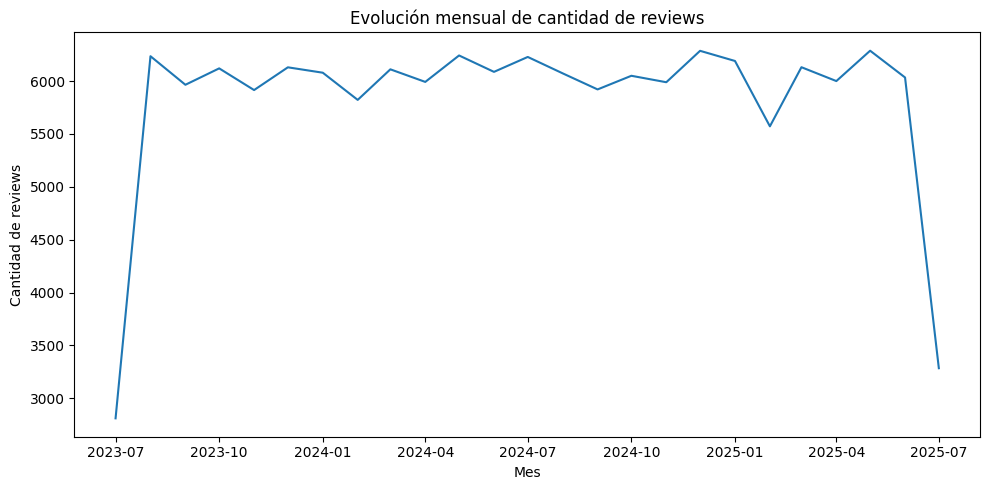

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

df_reviews_month = (
    df_reviews_clean
      .set_index('created_at')
      .resample('MS')
      .size()
      .rename('reviews_count')
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=df_reviews_month, x='created_at', y='reviews_count')
plt.title('Evolución mensual de cantidad de reviews')
plt.xlabel('Mes'); plt.ylabel('Cantidad de reviews')
plt.tight_layout(); plt.show()

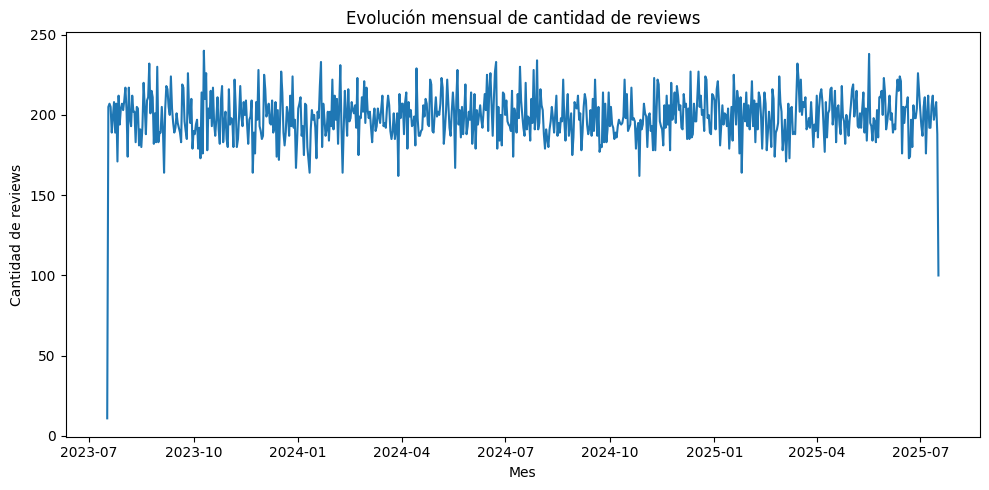

In [29]:
df_reviews_day = (
    df_reviews_clean
      .set_index('created_at')
      .resample('D').size()
      .asfreq('D', fill_value=0)
      .rename('reviews_count')
      .reset_index()
)


plt.figure(figsize=(10,5))
sns.lineplot(data=df_reviews_day, x='created_at', y='reviews_count')
plt.title('Evolución diaria de cantidad de reviews')
plt.xlabel('Mes'); plt.ylabel('Cantidad de reviews')
plt.tight_layout(); plt.show()